## Dropout in Neural Networks

In [13]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import torch
from torch import nn
from torch import optim
from torch.utils.data import DataLoader, TensorDataset
from sklearn.metrics import accuracy_score

In [14]:
df = pd.read_csv("data/sonar.all-data", header=None)
df.sample(3)

,0,1,2,3,4,5,6,7,8,9,10,11,12,13,14,15,16,17,18,19,20,21,22,23,24,25,26,27,28,29,30,31,32,33,34,35,36,37,38,39,40,41,42,43,44,45,46,47,48,49,50,51,52,53,54,55,56,57,58,59,60
65,0.0176,0.0172,0.0501,0.0285,0.0262,0.0351,0.0362,0.0535,0.0258,0.0474,0.0526,0.1854,0.1040,0.0948,0.0912,0.1688,0.1568,0.0375,0.1316,0.2086,0.1976,0.0946,0.1965,0.1242,0.0616,0.2141,0.4642,0.6471,0.6340,0.6107,0.7046,0.5376,0.5934,0.8443,0.9481,0.9705,0.7766,0.6313,0.5760,0.6148,0.5450,0.4813,0.3406,0.1916,0.1134,0.0640,0.0911,0.0980,0.0563,0.0187,0.0088,0.0042,0.0175,0.0171,0.0079,0.0050,0.0112,0.0179,0.0294,0.0063,R
191,0.0315,0.0252,0.0167,0.0479,0.0902,0.1057,0.1024,0.1209,0.1241,0.1533,0.2128,0.2536,0.2686,0.2803,0.1886,0.1485,0.2160,0.2417,0.2989,0.3341,0.3786,0.3956,0.5232,0.6913,0.7868,0.8337,0.9199,1.0000,0.8990,0.6456,0.5967,0.4355,0.2997,0.2294,0.1866,0.0922,0.1829,0.1743,0.2452,0.2407,0.2518,0.3184,0.1685,0.0675,0.1186,0.1833,0.1878,0.1114,0.0310,0.0143,0.0138,0.0108,0.0062,0.0044,0.0072,0.0007,0.0054,0.0035,0.0001,0.0055,M
55,0.0201,0.0116,0.0123,0.0245,0.0547,0.0208,0.0891,0.0836,0.1335,0.1199,0.1742,0.1387,0.2042,0.2580,0.2616,0.2097,0.2532,0.3213,0.4327,0.4760,0.5328,0.6057,0.6696,0.7476,0.8930,0.9405,1.0000,0.9785,0.8473,0.7639,0.6701,0.4989,0.3718,0.2196,0.1416,0.2680,0.2630,0.3104,0.3392,0.2123,0.1170,0.2655,0.2203,0.1541,0.1464,0.1044,0.1225,0.0745,0.0490,0.0224,0.0032,0.0076,0.0045,0.0056,0.0075,0.0037,0.0045,0.0029,0.0008,0.0018,R


In [15]:
df.shape

(208, 61)

In [16]:
df[60].value_counts()

60
M    111
R     97
Name: count, dtype: int64

In [17]:
df[60] = df[60].map({'M' : 0, 'R' : 1})
df.head(3)

,0,1,2,3,4,5,6,7,8,9,10,11,12,13,14,15,16,17,18,19,20,21,22,23,24,25,26,27,28,29,30,31,32,33,34,35,36,37,38,39,40,41,42,43,44,45,46,47,48,49,50,51,52,53,54,55,56,57,58,59,60
0,0.0200,0.0371,0.0428,0.0207,0.0954,0.0986,0.1539,0.1601,0.3109,0.2111,0.1609,0.1582,0.2238,0.0645,0.0660,0.2273,0.3100,0.2999,0.5078,0.4797,0.5783,0.5071,0.4328,0.5550,0.6711,0.6415,0.7104,0.8080,0.6791,0.3857,0.1307,0.2604,0.5121,0.7547,0.8537,0.8507,0.6692,0.6097,0.4943,0.2744,0.0510,0.2834,0.2825,0.4256,0.2641,0.1386,0.1051,0.1343,0.0383,0.0324,0.0232,0.0027,0.0065,0.0159,0.0072,0.0167,0.0180,0.0084,0.0090,0.0032,1
1,0.0453,0.0523,0.0843,0.0689,0.1183,0.2583,0.2156,0.3481,0.3337,0.2872,0.4918,0.6552,0.6919,0.7797,0.7464,0.9444,1.0000,0.8874,0.8024,0.7818,0.5212,0.4052,0.3957,0.3914,0.3250,0.3200,0.3271,0.2767,0.4423,0.2028,0.3788,0.2947,0.1984,0.2341,0.1306,0.4182,0.3835,0.1057,0.1840,0.1970,0.1674,0.0583,0.1401,0.1628,0.0621,0.0203,0.0530,0.0742,0.0409,0.0061,0.0125,0.0084,0.0089,0.0048,0.0094,0.0191,0.0140,0.0049,0.0052,0.0044,1
2,0.0262,0.0582,0.1099,0.1083,0.0974,0.2280,0.2431,0.3771,0.5598,0.6194,0.6333,0.7060,0.5544,0.5320,0.6479,0.6931,0.6759,0.7551,0.8929,0.8619,0.7974,0.6737,0.4293,0.3648,0.5331,0.2413,0.5070,0.8533,0.6036,0.8514,0.8512,0.5045,0.1862,0.2709,0.4232,0.3043,0.6116,0.6756,0.5375,0.4719,0.4647,0.2587,0.2129,0.2222,0.2111,0.0176,0.1348,0.0744,0.0130,0.0106,0.0033,0.0232,0.0166,0.0095,0.0180,0.0244,0.0316,0.0164,0.0095,0.0078,1


In [18]:
X = df.drop(60, axis=1)
y = df[60]

from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=1)

In [19]:
X_train_tensor = torch.tensor(X_train.values, dtype=torch.float32)
X_test_tensor = torch.tensor(X_test.values, dtype=torch.float32)
y_train_tensor = torch.tensor(y_train.values, dtype=torch.long)
y_test_tensor = torch.tensor(y_test.values, dtype=torch.long)

In [20]:
train_dataset = TensorDataset(X_train_tensor, y_train_tensor)
test_dataset = TensorDataset(X_test_tensor, y_test_tensor)

train_loader = DataLoader(train_dataset, batch_size=16, shuffle=True)
test_loader = DataLoader(test_dataset, batch_size=16, shuffle=True)

In [21]:
class SimpleNN(nn.Module):
    def __init__(self):
        super().__init__()
        self.network = nn.Sequential(
            nn.Linear(60, 128),
            nn.ReLU(),
            nn.Linear(128, 64),
            nn.ReLU(),
            nn.Linear(64, 2)
        )

    def forward(self, x):
        return self.network(x)

In [22]:
# Training function
def train_model(model, train_loader, val_loader, criterion, optimizer, epochs=20):
    train_losses, val_losses, val_accuracies = [], [], []
    for epoch in range(epochs):
        model.train()
        running_loss = 0.0
        for inputs, labels in train_loader:
            optimizer.zero_grad()
            outputs = model(inputs)
            loss = criterion(outputs, labels)
            loss.backward()
            optimizer.step()
            running_loss += loss.item()
        train_losses.append(running_loss / len(train_loader))
        
        # Validation phase
        model.eval()
        val_loss = 0.0
        y_pred, y_true = [], []
        with torch.no_grad():
            for inputs, labels in val_loader:
                outputs = model(inputs)
                loss = criterion(outputs, labels)
                val_loss += loss.item()
                _, predicted = torch.max(outputs, 1)
                y_pred.extend(predicted.cpu().numpy())
                y_true.extend(labels.cpu().numpy())
        val_losses.append(val_loss / len(val_loader))
        val_accuracy = accuracy_score(y_true, y_pred)
        val_accuracies.append(val_accuracy)
        
        print(f"Epoch {epoch+1}/{epochs}, Train Loss: {train_losses[-1]:.4f}, Val Loss: {val_losses[-1]:.4f}, Val Accuracy: {val_accuracy:.4f}")
    
    return train_losses, val_losses, val_accuracies

Epoch 1/20, Train Loss: 0.6865, Val Loss: 0.6914, Val Accuracy: 0.4762
Epoch 2/20, Train Loss: 0.6736, Val Loss: 0.6748, Val Accuracy: 0.4762
Epoch 3/20, Train Loss: 0.6514, Val Loss: 0.6464, Val Accuracy: 0.5714
Epoch 4/20, Train Loss: 0.6360, Val Loss: 0.6188, Val Accuracy: 0.6429
Epoch 5/20, Train Loss: 0.6021, Val Loss: 0.5922, Val Accuracy: 0.7619
Epoch 6/20, Train Loss: 0.5720, Val Loss: 0.5754, Val Accuracy: 0.6905
Epoch 7/20, Train Loss: 0.5364, Val Loss: 0.5159, Val Accuracy: 0.7619
Epoch 8/20, Train Loss: 0.4844, Val Loss: 0.5021, Val Accuracy: 0.7143
Epoch 9/20, Train Loss: 0.4466, Val Loss: 0.5411, Val Accuracy: 0.7381
Epoch 10/20, Train Loss: 0.4528, Val Loss: 0.4812, Val Accuracy: 0.7857
Epoch 11/20, Train Loss: 0.4159, Val Loss: 0.4312, Val Accuracy: 0.7619
Epoch 12/20, Train Loss: 0.3901, Val Loss: 0.5017, Val Accuracy: 0.7143
Epoch 13/20, Train Loss: 0.3708, Val Loss: 0.4676, Val Accuracy: 0.7619
Epoch 14/20, Train Loss: 0.3530, Val Loss: 0.4576, Val Accuracy: 0.7857
E

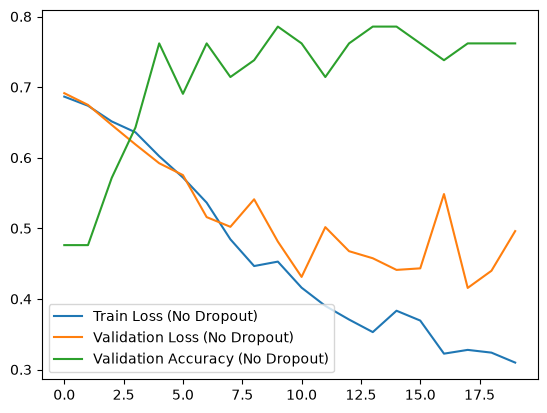

In [25]:
# Initialize and train the model without dropout
model_without_dropout = SimpleNN()
criterion = nn.CrossEntropyLoss()
optimizer = optim.Adam(model_without_dropout.parameters(), lr=0.001)

train_losses_no_dropout, val_losses_no_dropout, val_accuracies_no_dropout = train_model(
    model_without_dropout, train_loader, test_loader, criterion, optimizer, epochs=20
)

# Plot training and validation loss and accuracy (Without Dropout)
plt.plot(train_losses_no_dropout, label="Train Loss (No Dropout)")
plt.plot(val_losses_no_dropout, label="Validation Loss (No Dropout)")
plt.plot(val_accuracies_no_dropout, label="Validation Accuracy (No Dropout)")
plt.legend()
plt.show()

In [26]:
class SimpleNNWithDropout(nn.Module):
    def __init__(self):
        super().__init__()
        self.network = nn.Sequential(
            nn.Linear(60, 128),
            nn.ReLU(),
            nn.Dropout(p=0.5),
            nn.Linear(128, 64),
            nn.ReLU(),
            nn.Dropout(p=0.5),
            nn.Linear(64, 2)
        )

    def forward(self, x):
        return self.network(x)

Epoch 1/20, Train Loss: 0.6887, Val Loss: 0.6933, Val Accuracy: 0.4762
Epoch 2/20, Train Loss: 0.6817, Val Loss: 0.6905, Val Accuracy: 0.4762
Epoch 3/20, Train Loss: 0.6741, Val Loss: 0.6911, Val Accuracy: 0.4762
Epoch 4/20, Train Loss: 0.6766, Val Loss: 0.6706, Val Accuracy: 0.4762
Epoch 5/20, Train Loss: 0.6738, Val Loss: 0.6665, Val Accuracy: 0.4762
Epoch 6/20, Train Loss: 0.6677, Val Loss: 0.6614, Val Accuracy: 0.5952
Epoch 7/20, Train Loss: 0.6494, Val Loss: 0.6442, Val Accuracy: 0.6667
Epoch 8/20, Train Loss: 0.6434, Val Loss: 0.6264, Val Accuracy: 0.5952
Epoch 9/20, Train Loss: 0.6385, Val Loss: 0.6163, Val Accuracy: 0.6429
Epoch 10/20, Train Loss: 0.6268, Val Loss: 0.5794, Val Accuracy: 0.6905
Epoch 11/20, Train Loss: 0.6022, Val Loss: 0.5786, Val Accuracy: 0.6905
Epoch 12/20, Train Loss: 0.5896, Val Loss: 0.5430, Val Accuracy: 0.7619
Epoch 13/20, Train Loss: 0.5536, Val Loss: 0.5172, Val Accuracy: 0.7619
Epoch 14/20, Train Loss: 0.5828, Val Loss: 0.5239, Val Accuracy: 0.7619
E

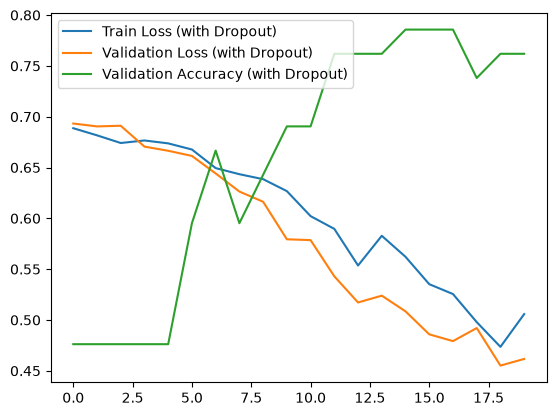

In [27]:
# Initialize and train the model with dropout
model_with_dropout = SimpleNNWithDropout()
criterion = nn.CrossEntropyLoss()
optimizer = optim.Adam(model_with_dropout.parameters(), lr=0.001)

train_losses_with_dropout, val_losses_with_dropout, val_accuracies_with_dropout = train_model(
    model_with_dropout, train_loader, test_loader, criterion, optimizer, epochs=20
)

# Plot training and validation loss and accuracy (With Dropout)
plt.plot(train_losses_with_dropout, label="Train Loss (with Dropout)")
plt.plot(val_losses_with_dropout, label="Validation Loss (with Dropout)")
plt.plot(val_accuracies_with_dropout, label="Validation Accuracy (with Dropout)")
plt.legend()
plt.show()